# EDA: кандидатогенерация для поиска услуг Авито

In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 150)
pd.set_option("display.width", 200)

DATA_DIR = Path("data")  # поменяйте на папку, куда распаковали архив

train   = pd.read_parquet(DATA_DIR / "train.parquet")
queries = pd.read_parquet(DATA_DIR / "benchmark_queries.parquet")
items   = pd.read_parquet(DATA_DIR / "benchmark_items.parquet")

NUM_COLS = ["item_latitude", "item_longitude", "item_price", "item_rating",
            "item_rating_reviews_count", "item_is_phone_hidden", "item_is_message_forbidden",
            "search_is_delivery_search"]

for df in (train, queries, items):
    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

for name, df in [("train", train), ("queries", queries), ("items", items)]:
    print(f"{name:8s} {df.shape}")

train    (497673, 19)
queries  (2452, 6)
items    (189212, 14)


## 0. Общий обзор: типы, пропуски, уникальные значения

In [ ]:
def overview(df):
    empty_str = df.apply(lambda c: (c.astype(str).str.strip() == "").mean() if c.dtype == object else 0.0)
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "null_%": (df.isna().mean() * 100).round(2),
        "empty_str_%": (empty_str * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

display(overview(train))
display(overview(queries))
display(overview(items))

,dtype,null_%,empty_str_%,n_unique
search_query,object,0.00,0.00,74529
search_location_id,int64,0.00,0.00,2782
search_is_delivery_search,float64,0.00,0.00,2
search_infm_params_text,object,0.00,32.95,3724
search_category,int64,0.00,0.00,4
item_title_raw,object,0.00,0.00,210029
item_rating_reviews_count,float64,3.86,0.00,1372
item_rating,float64,5.67,0.00,8832
item_price,float64,0.00,0.00,2992
item_microcat_id,int64,0.00,0.00,212


,dtype,null_%,empty_str_%,n_unique
query_id,object,0.0,0.00,2452
search_query,object,0.0,0.00,2452
search_location_id,int64,0.0,0.00,273
search_is_delivery_search,float64,0.0,0.00,1
search_infm_params_text,object,0.0,63.05,132
search_category,int64,0.0,0.00,2


,dtype,null_%,empty_str_%,n_unique
item_title_raw,object,0.00,0.0,119952
item_rating_reviews_count,float64,6.14,0.0,1170
item_rating,float64,9.32,0.0,6007
item_price,float64,0.00,0.0,2949
item_microcat_id,int64,0.00,0.0,752
item_longitude,float64,0.00,0.0,120004
item_location_id,int64,0.00,0.0,2877
item_latitude,float64,0.00,0.0,119778
item_is_phone_hidden,float64,0.00,0.0,2
item_is_message_forbidden,float64,0.00,0.0,2


In [ ]:
display(train.head(7).T)

,0,1,2,3,4,5,6
search_query,скупка телевизоров,автоподбор,баня на дровах,изготовление госномера на авто,укладка плитки,сборка мебели,наращивание ногтей
search_location_id,652430,640860,653240,634670,658430,639550,107620
search_is_delivery_search,0.0,0.0,0.0,0.0,0.0,0.0,0.0
search_infm_params_text,,Рейтинг пользователя 4 звезды и выше,"Онлайн-запись Тип услуги СПА-услуги, массаж Вид услуги Красота, здоровье","Вид услуги Оборудование, производство",Тип услуги Ремонт квартир и домов под ключ Вид услуги Ремонт и отделка,Тип услуги Сборка и ремонт мебели Вид услуги Ремонт и отделка,"Онлайн-запись Тип услуги Маникюр, педикюр Вид услуги Красота, здоровье"
search_category,114,114,114,114,114,114,114
item_title_raw,Скупка б/у техники,Автоподбор Разовый осмотр автомобиля,"Баня на дровах ""Прованс"" на Цветочной","Изготовление дубликатов авто номеров, гос номеров",Ремонт и отделка квартир под ключ,Сборка мебели,Мастер маникюр и педикюра
item_rating_reviews_count,91.0,462.0,NaN,14.0,1.0,27.0,47.0
item_rating,4.989011,4.982684,NaN,4.714286,5.0,5.0,4.914894
item_price,1.0,3500.0,1600.0,1700.0,1000.0,1500.0,700.0
item_microcat_id,2303374,2303374,86469,2303428,44725,44732,86470


In [ ]:
def norm(s: pd.Series) -> pd.Series:
    return (s.fillna("").astype(str).str.lower()
             .str.replace("ё", "е", regex=False)
             .str.replace(r"\s+", " ", regex=True)
             .str.strip())

train["q_norm"] = norm(train["search_query"])
queries["q_norm"] = norm(queries["search_query"])

# «Поисковая сессия» = уникальная комбинация всех признаков запроса
Q_COLS = ["search_query", "search_location_id", "search_is_delivery_search",
          "search_infm_params_text", "search_category"]
train["q_key"] = train.groupby(Q_COLS, dropna=False).ngroup()

print("Полных дублей строк в train:", train.duplicated(subset=Q_COLS + ["item_id"]).sum())

Полных дублей строк в train: 30619


## 1. Запросы: сколько их, какие они

In [ ]:
print("Уникальных текстов запросов (train):    ", train["q_norm"].nunique())
print("Уникальных наборов признаков запроса:   ", train["q_key"].nunique())
print("Уникальных текстов запросов (benchmark):", queries["q_norm"].nunique(), "из", len(queries))

q_len = train.drop_duplicates("q_key")["q_norm"].str.split().str.len()
print("\nДлина запроса в словах:")
print(q_len.value_counts().sort_index().head(10))

print("\nТоп-30 запросов в train:")
display(train["q_norm"].value_counts().head(30))

Уникальных текстов запросов (train):     73873
Уникальных наборов признаков запроса:    354463
Уникальных текстов запросов (benchmark): 2451 из 2452

Длина запроса в словах:
q_norm
1      56049
2     155704
3      89265
4      38205
5      11045
6       2956
7        909
8        239
9         63
10         8
Name: count, dtype: int64

Топ-30 запросов в train:


q_norm
маникюр                          6540
массаж                           5702
наращивание ресниц               5397
установка кондиционеров          4576
педикюр                          3436
сантехник                        3405
вывоз мусора                     3288
эвакуатор                        3263
электрик                         3158
автоэлектрик                     2790
покос травы                      2484
вспашка земли                    2316
манипулятор                      2120
грузоперевозки газель            2034
натяжные потолки                 2004
наращивание ногтей               1902
торты на заказ                   1682
тонировка                        1644
поклейка обоев                   1611
грузчики                         1540
покраска авто                    1510
грузоперевозки                   1492
установка межкомнатных дверей    1443
заправка кондиционера            1408
выкуп авто                       1331
автоподбор                       1321
тонир

Выбранных объявлений на один запрос:
count    354463.000000
mean          1.317638
std           1.611180
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         278.000000
Name: item_id, dtype: float64


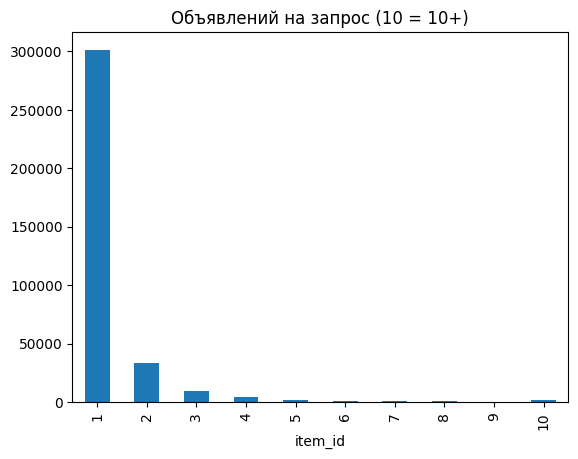

In [ ]:
per_key = train.groupby("q_key")["item_id"].nunique()
print("Выбранных объявлений на один запрос:")
print(per_key.describe())
per_key.clip(upper=10).value_counts().sort_index().plot.bar(title="Объявлений на запрос (10 = 10+)")
plt.show()

In [ ]:
print("Доля запросов с поиском с доставкой:")
print(train.drop_duplicates("q_key")["search_is_delivery_search"].value_counts(normalize=True))

print("\nТоп фильтров search_infm_params_text:")
display(norm(train["search_infm_params_text"]).value_counts().head(20))

print("\nТоп search_category:")
display(train["search_category"].value_counts(dropna=False).head(20))

Доля запросов с поиском с доставкой:
search_is_delivery_search
0.0    0.999969
1.0    0.000031
Name: proportion, dtype: float64

Топ фильтров search_infm_params_text:


search_infm_params_text
                                                                                                        163999
вид услуги автосервис, аренда тип услуги автосервис                                                      19654
вид услуги ремонт и отделка                                                                              15586
вид услуги красота, здоровье                                                                             15355
вид услуги праздники, мероприятия                                                                        12474
тип услуги автосервиса диагностика и ремонт авто вид услуги автосервис, аренда тип услуги автосервис     11644
тип услуги маникюр, педикюр вид услуги красота, здоровье                                                 11589
вид услуги обучение, курсы                                                                               11080
вид услуги                                                                              


Топ search_category:


search_category
114    497635
0          34
81          2
10          2
Name: count, dtype: int64

## 2. Локация - главный критерий

In [ ]:
train["loc_match"] = train["search_location_id"] == train["item_location_id"]

print(f"Совпадение локации запроса и объявления: {train['loc_match'].mean():.3f}")
display(train.groupby("search_is_delivery_search")["loc_match"].agg(["mean", "size"]))

print("Уникальных локаций поиска:", train["search_location_id"].nunique())
print("Уникальных локаций объявлений в корпусе:", items["item_location_id"].nunique())

Совпадение локации запроса и объявления: 0.831


,mean,size
search_is_delivery_search,,
0.0,0.831028,497661
1.0,0.500000,12


Уникальных локаций поиска: 2782
Уникальных локаций объявлений в корпусе: 2877


In [ ]:
# Когда локации не совпадают — это соседние города? Смотрим, что за пары
mismatch = train.loc[~train["loc_match"], ["search_location_id", "item_location_id"]]
display(mismatch.value_counts().head(20))

search_location_id  item_location_id
107620              637640              7517
107621              653240              5016
621540              637640              1870
632660              633540               930
629990              630090               868
621540              653240               732
651110              652000               677
640310              640860               654
652560              653040               610
660710              661420               600
641470              641780               579
653700              654070               568
660711              653391               510
646710              647420               483
637640              637641               482
625670              625810               480
621550              621565               435
634748              634450               426
629430              629770               379
642020              642320               362
Name: count, dtype: int64

In [ ]:
# Можно ли восстановить «центр» локации поиска по координатам объявлений
# и понять, насколько далеко находятся выбранные объявления из других локаций
loc_center = (items.groupby("item_location_id")[["item_latitude", "item_longitude"]]
                   .median().rename(columns={"item_latitude": "c_lat", "item_longitude": "c_lon"}))

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

m = train.loc[~train["loc_match"]].join(loc_center, on="search_location_id")
m["dist_km"] = haversine_km(m["c_lat"], m["c_lon"], m["item_latitude"], m["item_longitude"])
print("Расстояние от центра локации поиска до объявления (при несовпадении локаций), км:")
print(m["dist_km"].describe(percentiles=[.25, .5, .75, .9, .95]))

Расстояние от центра локации поиска до объявления (при несовпадении локаций), км:
count    29866.000000
mean       213.403910
std        646.670771
min          0.088007
25%         17.677041
50%         34.420468
75%        100.299887
90%        499.335077
95%       1162.480873
max      14773.145959
Name: dist_km, dtype: float64


## 3. Категории: насколько запрос определяет, где искать

`topk_coverage` показывает: если для каждого запроса взять k самых частых подкатегорий из train,
какая доля выбранных объявлений в них попадёт

In [ ]:
def topk_coverage(df, key, target, k):
    cnt = df.groupby([key, target], dropna=False).size().rename("n").reset_index()
    cnt["rank"] = cnt.groupby(key)["n"].rank(method="first", ascending=False)
    return cnt.loc[cnt["rank"] <= k, "n"].sum() / cnt["n"].sum()

for key in ["search_category", "q_norm"]:
    for target in ["item_category_id", "item_microcat_id"]:
        cov = {k: round(topk_coverage(train, key, target, k), 3) for k in [1, 3, 5, 10]}
        print(f"{key:16s} -> {target:17s} {cov}")

search_category  -> item_category_id  {1: np.float64(1.0), 3: np.float64(1.0), 5: np.float64(1.0), 10: np.float64(1.0)}
search_category  -> item_microcat_id  {1: np.float64(0.058), 3: np.float64(0.127), 5: np.float64(0.176), 10: np.float64(0.27)}
q_norm           -> item_category_id  {1: np.float64(1.0), 3: np.float64(1.0), 5: np.float64(1.0), 10: np.float64(1.0)}
q_norm           -> item_microcat_id  {1: np.float64(0.863), 3: np.float64(0.977), 5: np.float64(0.992), 10: np.float64(0.999)}


In [ ]:
print("Уникальных категорий:", train["item_category_id"].nunique(),
      "| подкатегорий:", train["item_microcat_id"].nunique())
display(pd.crosstab(train["search_category"], train["item_category_id"]).iloc[:15, :15])

Уникальных категорий: 8 | подкатегорий: 212


item_category_id,10,19,27,28,40,81,112,114
search_category,,,,,,,,
0,0,0,0,0,0,0,0,34
10,0,0,0,0,0,0,0,2
81,0,0,0,0,0,0,0,2
114,1,2,4,2,2,2,2,497620


## 4. Пересечение train и benchmark

In [ ]:
train_q = set(train["q_norm"])
bench_in_train = queries["q_norm"].isin(train_q)
print(f"Benchmark-запросов, чей текст встречался в train: {bench_in_train.mean():.3f}")

pair_train = set(zip(train["q_norm"], train["search_location_id"]))
pair_bench = pd.Series(list(zip(queries["q_norm"], queries["search_location_id"])))
print(f"...с той же локацией: {pair_bench.isin(pair_train).mean():.3f}")

print(f"\nОбъявлений корпуса, встречавшихся в train: {items['item_id'].isin(set(train['item_id'])).mean():.3f}")
print(f"Уникальных item_id в train: {train['item_id'].nunique()}")

print(f"\nЛокаций benchmark, встречавшихся в train: "
      f"{queries['search_location_id'].isin(set(train['search_location_id'])).mean():.3f}")

print("\nЧастые benchmark-запросы, которых НЕТ в train:")
display(queries.loc[~bench_in_train, "q_norm"].value_counts().head(20))

Benchmark-запросов, чей текст встречался в train: 0.374
...с той же локацией: 0.066

Объявлений корпуса, встречавшихся в train: 0.096
Уникальных item_id в train: 344825

Локаций benchmark, встречавшихся в train: 1.000

Частые benchmark-запросы, которых НЕТ в train:


q_norm
сопровождающая суворовский              1
переводчик книг                         1
грузовики для переезда                  1
муж на час ивантеевка                   1
место мастера педикюра                  1
шлифмашинка в аренду                    1
грузоперевозки ильина                   1
ремонт телевизоров на дому кудрого      1
печать наклеек надписей                 1
клизма                                  1
печать и оклейка авто                   1
ремонт газонокосилок и микроволновок    1
экстремальный клининг                   1
парикмахер афро                         1
прочистка труб водопровода              1
услуги катание на мотоцикле эндуро      1
регулировка окон schuco                 1
машина с подъемником                    1
ремонт дивана на дому                   1
няня на полный день                     1
Name: count, dtype: int64

In [ ]:
## 5. Размер пула кандидатов после фильтра по локации

Объявлений корпуса в локации запроса:
count     2452.000000
mean      4702.771207
std       6680.690163
min          0.000000
10%          0.000000
25%        368.750000
50%       1638.000000
75%       3659.000000
90%      19543.000000
max      19543.000000
Name: pool_loc, dtype: float64

Запросов с пустым пулом: 0.174
Запросов с пулом <= 50 (фильтр по локации уже решает задачу): 0.178


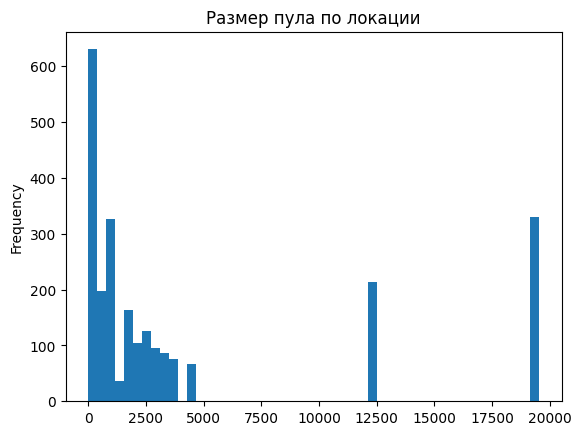

In [ ]:
loc_counts = items["item_location_id"].value_counts()
queries["pool_loc"] = queries["search_location_id"].map(loc_counts).fillna(0).astype(int)

print("Объявлений корпуса в локации запроса:")
print(queries["pool_loc"].describe(percentiles=[.1, .25, .5, .75, .9]))
print(f"\nЗапросов с пустым пулом: {(queries['pool_loc'] == 0).mean():.3f}")
print(f"Запросов с пулом <= 50 (фильтр по локации уже решает задачу): {(queries['pool_loc'] <= 50).mean():.3f}")

queries["pool_loc"].clip(upper=20000).plot.hist(bins=50, title="Размер пула по локации")
plt.show()

## 6. Тексты объявлений

In [ ]:
for col in ["item_title_raw", "item_description_raw", "item_infm_params_text"]:
    s = items[col].fillna("").astype(str)
    n_words = s.str.split().str.len()
    print(f"{col:24s} пусто: {(s.str.strip() == '').mean():.3f} | "
          f"слов: медиана {n_words.median():.0f}, p90 {n_words.quantile(.9):.0f}, max {n_words.max()}")

print("\nПримеры параметров объявлений:")
display(items["item_infm_params_text"].dropna().sample(10, random_state=0))
print("\nПримеры заголовков:")
display(items["item_title_raw"].sample(15, random_state=0))

item_title_raw           пусто: 0.000 | слов: медиана 4, p90 7, max 20
item_description_raw     пусто: 0.000 | слов: медиана 147, p90 430, max 1568
item_infm_params_text    пусто: 0.000 | слов: медиана 110, p90 272, max 2468

Примеры параметров объявлений:


169635    Вид услуги Красота, здоровье Место оказания услуг Москва, 1-й Колобовский переулок, 23 Тип услуги Аренда рабочего места Тип стоимости за день Нача...
154169    Вид услуги Красота, здоровье Место оказания услуг Республика Башкортостан, Нефтекамск, улица Карла Маркса, 7 Тип услуги Косметология Тип стоимости...
180216    Вид услуги Обучение, курсы Место оказания услуг Ростов-на-Дону, Ворошиловский проспект, 16/71 Тип услуги Предметы школы и вуза Тип стоимости за ус...
102149    Вид услуги Ремонт и отделка Тип услуги Сборка и ремонт мебели Место оказания услуг Самара, Товарная улица, 5к22 Тип стоимости за услугу Начальная ...
162862    Вид услуги Деловые услуги Тип услуги Место оказания услуг Новосибирская обл., Новосибирск Тип стоимости за услугу Название услуги Разбор маркетинг...
18025     Вид товара Запчасти Тип товара Для автомобилей Вид запчасти Стёкла Вид объявления Товар от производителя Место сделки Московская обл., Балашиха, у...
53863     Вид услуги Сад, благоустройств


Примеры заголовков:


169635       Аренда кресла для парикмахера / колориста центр
154169                              Косметологические услуги
180216         Решение задач по математике/высшей математике
102149       Замена фасадов и столешниц. Переделка гарнитура
162862              Услуги маркетолога, маркетинговый разбор
18025         Лобовое стекло на Audi A6(С6) 4D Sedan (04-10)
53863                                     Бригада землекопов
22919                     Ремонт АКПП и Вариатора всех видов
148796        Ремонт стиральных машин с гарантией (выезд 0р)
44625                            Ремонт посудомоечной машины
103975                               Опытный психолог онлайн
180129                         Услуги манипулятора 5-10 тонн
91709     Атермальная Тонировка / Тонировка авто / Тонировка
187302       Изготовление коробок для косметики и парфюмерии
74243       Стикеры /наклейка/ самоклейка / плоттерная резка
Name: item_title_raw, dtype: object

## 7. Лексическое совпадение запроса и объявления

In [ ]:
TOKEN_RE = re.compile(r"\w+")

def stems(text):
    return {w[:5] for w in TOKEN_RE.findall(str(text).lower().replace("ё", "е")) if len(w) > 2}

sample = train.sample(min(50_000, len(train)), random_state=0)
q_st = sample["search_query"].map(stems)
title_st = sample["item_title_raw"].map(stems)
params_st = sample["item_infm_params_text"].map(stems)
desc_st = sample["item_description_raw"].map(stems)

def share_overlap(fields):
    return np.mean([bool(q & set().union(*f)) for q, *f in zip(q_st, *fields)])

print(f"Есть общее слово с заголовком:                 {share_overlap([title_st]):.3f}")
print(f"... с заголовком или параметрами:              {share_overlap([title_st, params_st]):.3f}")
print(f"... с заголовком, параметрами или описанием:   {share_overlap([title_st, params_st, desc_st]):.3f}")

Есть общее слово с заголовком:                 0.836
... с заголовком или параметрами:              0.916
... с заголовком, параметрами или описанием:   0.973


In [ ]:
no_overlap = [not (q & (t | p | d)) for q, t, p, d in zip(q_st, title_st, params_st, desc_st)]
print("Примеры пар без общих слов — здесь нужна семантика:")
display(sample.loc[no_overlap, ["search_query", "item_title_raw", "item_infm_params_text"]].head(20))

Примеры пар без общих слов — здесь нужна семантика:


,search_query,item_title_raw,item_infm_params_text
460736,афрейм аренда,A-Frame с банным чаном,"Вид услуги Праздники, мероприятия Место оказания услуг Ивановский район, Богданихское сельское поселение Тип стоимости за услугу Начальная цена На..."
475923,риелтор,Услуги риэлтора,Вид услуги Деловые услуги Тип услуги Место оказания услуг ул. Кижеватова Тип стоимости за услугу Начальная цена Опыт работы 8–10 лет Берёте ли сро...
302208,сдать стеклотару,"Прием стрейч пвд пленки архива,газеты","Вид услуги Вывоз мусора и вторсырья Место оказания услуг ул. Свободы, 13 Тип стоимости за услугу График работы от 32400 График работы до 64800 Гра..."
42533,пошив сумок,Вязанная сумка на заказ,"Вид услуги Искусство Место оказания услуг ул. Холмогорова, 11 Тип стоимости за услугу Начальная цена"
302765,копщики ям,Помощь на даче,"Вид услуги Сад, благоустройство Место оказания услуг Магистральная ул., 53Б Тип стоимости за услугу Начальная цена Тип услуги Другое Работа по дог..."
301332,провести газ,"Монтаж водопровода, канализации","Вид услуги Ремонт и отделка Тип услуги Сантехника Место оказания услуг Курская область, Курчатов, Коммунистический проспект Тип стоимости за услуг..."
155454,вспахать землю трактор,"Вспашка, покос травы, культивация","Вид услуги Сад, благоустройство Место оказания услуг Удмуртская Республика, Сарапул, улица Азина Тип стоимости за услугу Начальная цена Тип услуги..."
111902,косить траву,"Вспашка земли мотоблоком, покос травы триммером","Вид услуги Сад, благоустройство Место оказания услуг Оренбургский район, село Ивановка, улица Литераторов, 9 Тип стоимости за услугу Тип услуги Зе..."
306663,новакутан,Биоревитализация/Мезотерапия/Липолитики,"Вид услуги Красота, здоровье Место оказания услуг Краснодар, Центральный внутригородской округ, микрорайон Дубинка, улица Степана Разина, 72 Тип у..."
241463,сварщик,Сварка аргоном,"Вид услуги Автосервис, аренда Тип услуги Автосервис Место оказания услуг Пермский край, Березники, Новосодовая ул., 13 Гарантия Опыт работы 20 Тип..."


## 8. Числовые признаки: отличаются ли выбранные объявления от корпуса

In [ ]:
num_cols = ["item_price", "item_rating", "item_rating_reviews_count",
            "item_is_phone_hidden", "item_is_message_forbidden"]
chosen = train.drop_duplicates("item_id")[num_cols]

cmp = pd.DataFrame({
    "chosen_median": chosen.median(),
    "corpus_median": items[num_cols].median(),
    "chosen_mean": chosen.mean(),
    "corpus_mean": items[num_cols].mean(),
    "chosen_null_%": chosen.isna().mean() * 100,
    "corpus_null_%": items[num_cols].isna().mean() * 100,
}).round(3)
display(cmp)

,chosen_median,corpus_median,chosen_mean,corpus_mean,chosen_null_%,corpus_null_%
item_price,1000.0,1000.0,2.150652e+07,1.986029e+07,0.000,0.000
item_rating,5.0,5.0,4.800000e+00,4.789000e+00,6.748,9.318
item_rating_reviews_count,21.0,18.0,7.419900e+01,6.647700e+01,4.551,6.139
item_is_phone_hidden,0.0,0.0,1.280000e-01,1.560000e-01,0.000,0.000
item_is_message_forbidden,0.0,0.0,2.200000e-02,2.700000e-02,0.000,0.000


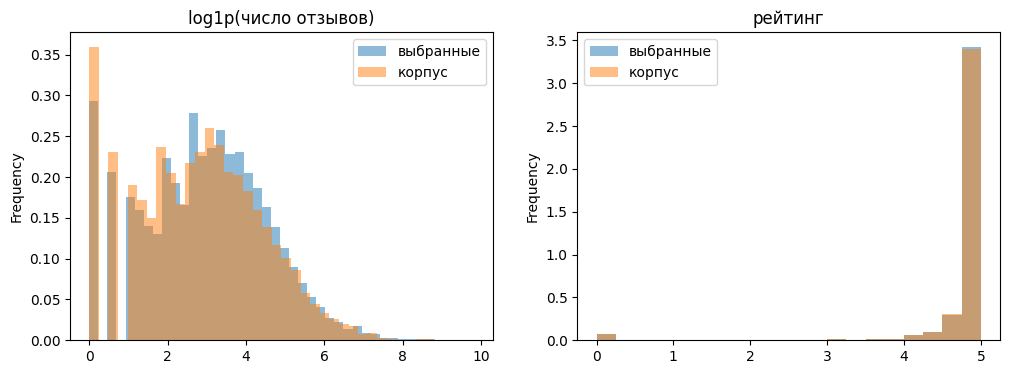

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
np.log1p(chosen["item_rating_reviews_count"].fillna(0)).plot.hist(bins=40, alpha=.5, density=True, ax=ax[0], label="выбранные")
np.log1p(items["item_rating_reviews_count"].fillna(0)).plot.hist(bins=40, alpha=.5, density=True, ax=ax[0], label="корпус")
ax[0].set_title("log1p(число отзывов)"); ax[0].legend()

chosen["item_rating"].plot.hist(bins=20, alpha=.5, density=True, ax=ax[1], label="выбранные")
items["item_rating"].plot.hist(bins=20, alpha=.5, density=True, ax=ax[1], label="корпус")
ax[1].set_title("рейтинг"); ax[1].legend()
plt.show()

## 9. Сводка

In [ ]:
summary = {
    "совпадение локации (все)": train["loc_match"].mean(),
    "совпадение локации (без доставки)": train.loc[train["search_is_delivery_search"] == 0, "loc_match"].mean(),
    "benchmark-запросы, встречавшиеся в train": bench_in_train.mean(),
    "объявления корпуса, встречавшиеся в train": items["item_id"].isin(set(train["item_id"])).mean(),
    "медианный пул по локации": queries["pool_loc"].median(),
    "покрытие top-3 подкатегорий по тексту запроса": topk_coverage(train, "q_norm", "item_microcat_id", 3),
    "пары с общим словом (заголовок+параметры)": share_overlap([title_st, params_st]),
}
pd.Series(summary).round(3)

совпадение локации (все)                            0.831
совпадение локации (без доставки)                   0.831
benchmark-запросы, встречавшиеся в train            0.374
объявления корпуса, встречавшиеся в train           0.096
медианный пул по локации                         1638.000
покрытие top-3 подкатегорий по тексту запроса       0.977
пары с общим словом (заголовок+параметры)           0.916
dtype: float64